# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need. 

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members
<span style="color: red;"><strong>TODO:</strong> Add your teamname and add the names of your team members</span>


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code. 
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [7]:
# imports
import textwrap
import math
import copy
from pathlib import Path
from collections import defaultdict
import kagglehub
import shutil
import os

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader,
    build_captions_map,
    load_split_dataframe,
    load_split_image_ids,
)
from tokenizer import tokenize, CaptionTokenizer

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

torch version: 2.6.0+cu118
torchvision version: 0.21.0+cpu


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/images`-folder. Make sure to download all the images and placing them in the folder `data/images/`. 
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

In [8]:
# 1. Download the dataset to the kagglehub cache
cache_path = kagglehub.dataset_download("adityajn105/flickr8k")

# 2. Define the target directory relative to where you run the code
target_dir = os.path.join(os.getcwd(), "data")

# 3. Copy the dataset files from the cache to your target folder
shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)

print(f"Dataset successfully saved to: {target_dir}")

Dataset successfully saved to: c:\Users\pd\Documents\ZHAW\mas_s1\semester 2\FTP_DeLearn\Projekte\neural-image-captioning\captioning_starter\data


## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. | 
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. | 
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. | 
| `<unk>`  | 3 | unknown - not available in vocabulary | 

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [9]:
# Transforms
IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    """Training transforms with data augmentation for regularisation."""
    return transforms.Compose([
        transforms.Lambda(_convert_to_rgb),
        # Data augmentation: helps generalisation on small dataset
        transforms.RandomResizedCrop(IMAGENET_SIZE, scale=(0.65, 1.0), ratio=(0.75, 1.33)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def build_test_transforms() -> transforms.Compose:
    """Deterministic test transforms — no augmentation."""
    return transforms.Compose([
        transforms.Lambda(_convert_to_rgb),
        transforms.Resize(256),
        transforms.CenterCrop(IMAGENET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalisation for visualisation."""
    mean_t = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_t  = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_t + mean_t).clamp(0, 1)

In [14]:
# TODO: ADJUST PATH TO data_dir IF NEEDED
data_dir = target_dir

MIN_WORD_FREQ = 5
MAX_LEN       = 40
BATCH_SIZE    = 32

In [16]:
# Build vocabulary from training captions only (no test leakage).
tokenizer = build_tokenizer_from_split(split="train", data_dir=data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_train_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all",
)
test_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random",
)

# Build reference captions map for BLEU evaluation
test_captions_df  = load_split_dataframe("test", data_dir)
test_captions_map = build_captions_map(test_captions_df)

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size:                {len(tokenizer):,}")
print(f"Number of training examples:    {len(train_loader.dataset):,}")
print(f"Batch image tensor shape:       {tuple(images.shape)}")
print(f"Batch caption tensor shape:     {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()[:6]} ...")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
print(f"Number of test examples:        {len(test_loader.dataset):,}")
print(f"Batch image tensor shape:       {tuple(images.shape)}")

Vocabulary size:                2,649
Number of training examples:    32,365
Batch image tensor shape:       (32, 3, 224, 224)
Batch caption tensor shape:     (32, 40)
Caption lengths in first batch: [13, 22, 16, 11, 9, 11] ...
Number of test examples:        1,618
Batch image tensor shape:       (32, 3, 224, 224)


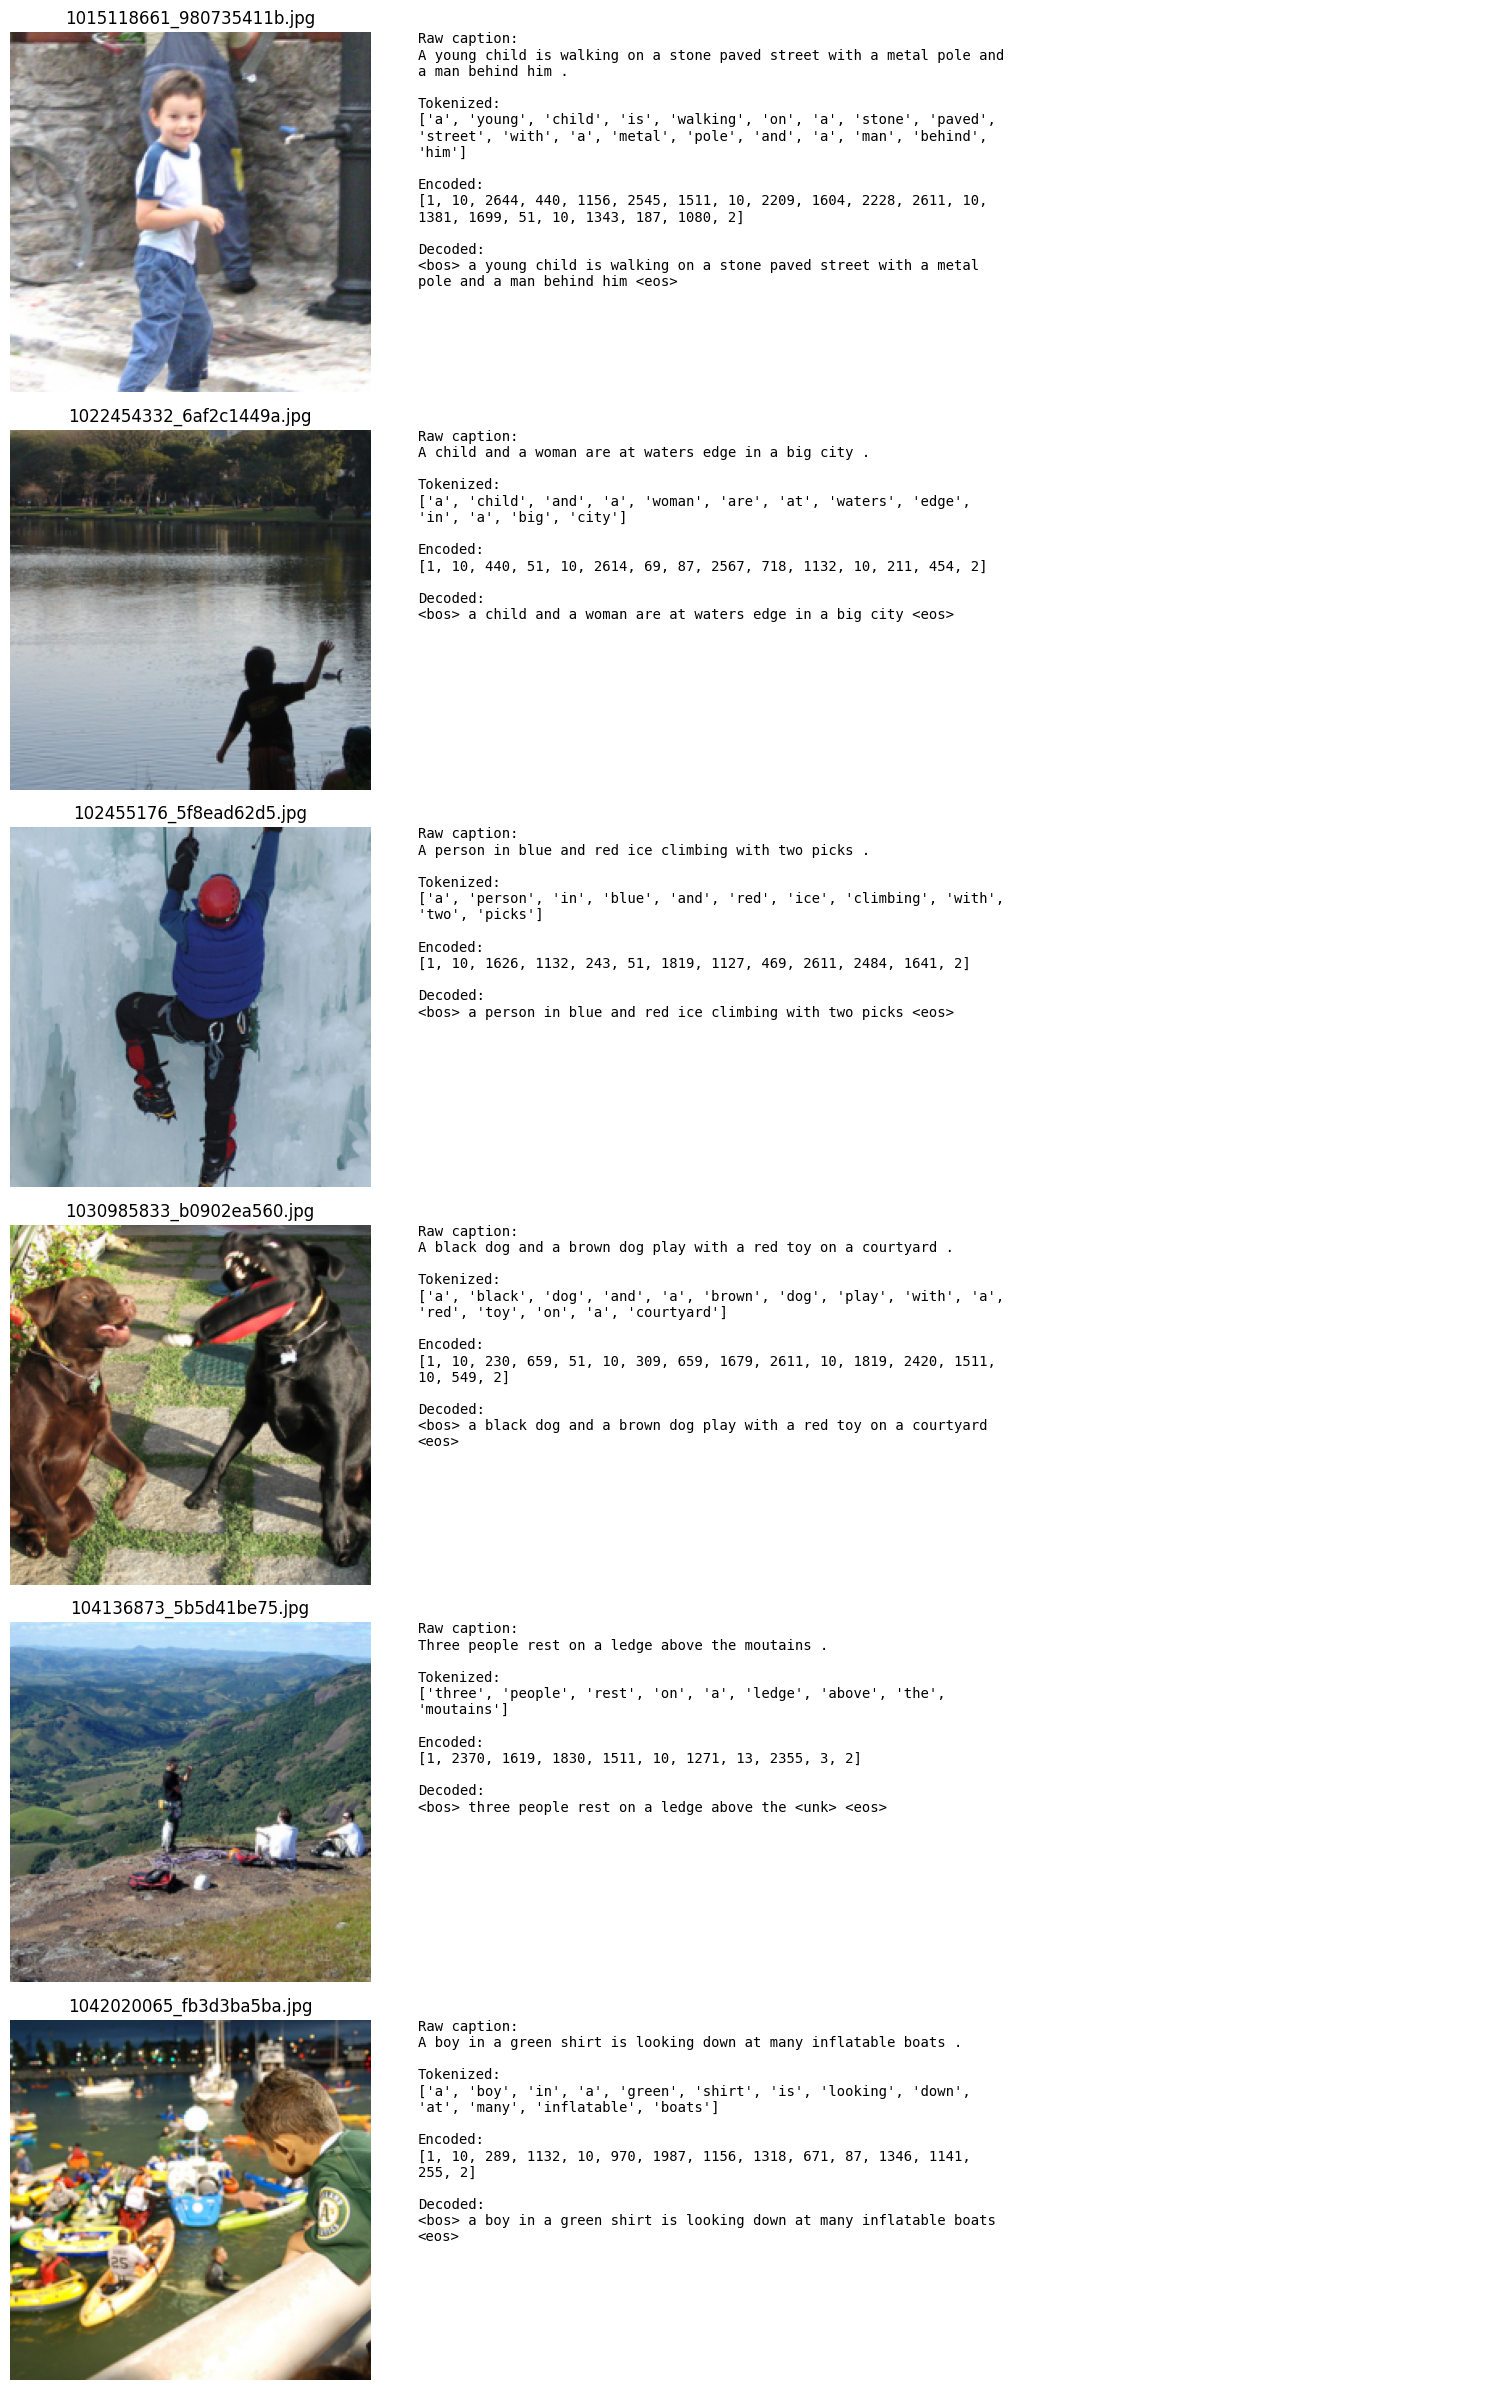

In [17]:
# Visualise a few samples from the test loader
num_examples = 6
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption  = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption   = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join([
        f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
        f"Tokenized:\n{textwrap.fill(str(tokenized_caption), width=70)}",
        f"Encoded:\n{textwrap.fill(str(encoded_caption), width=70)}",
        f"Decoded:\n{textwrap.fill(decoded_caption, width=70)}",
    ])

    ax_text.axis("off")
    ax_text.text(0, 1, caption_details, va="top", ha="left", fontsize=10, family="monospace")

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualisation helpers here. This way your model models stay directly comparable.


In [18]:
# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print("device:", DEVICE)

PAD_IDX = tokenizer.pad_idx  # == 0


# ── Loss helper ─────────────────────────────────────────────────────────────
def masked_cross_entropy(logits: torch.Tensor, targets: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    """Average cross-entropy over non-padding positions."""
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(-1, V), targets.reshape(-1), ignore_index=pad_idx)


# ── Training loop ──────────────────────────────────────────────────────────
def train_one_epoch(encoder, decoder, dataloader, optimizer, device, pad_idx=0) -> float:
    encoder.train()
    decoder.train()
    total_loss, n_batches = 0.0, 0
    for images, captions, lengths, _, _ in dataloader:
        images  = images.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        features = encoder(images)
        logits   = decoder(features, captions)          # (B, T-1, V)
        targets  = captions[:, 1:]                      # (B, T-1)
        loss = masked_cross_entropy(logits, targets, pad_idx)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()), max_norm=5.0
        )
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches


# ── Perplexity ──────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_perplexity(encoder, decoder, dataloader, device, pad_idx=0) -> float:
    """Token-level perplexity (sum loss / n_tokens, then exp)."""
    encoder.eval(); decoder.eval()
    total_loss, total_tokens = 0.0, 0
    for images, captions, lengths, _, _ in dataloader:
        images  = images.to(device)
        captions = captions.to(device)
        features = encoder(images)
        logits   = decoder(features, captions)
        targets  = captions[:, 1:]
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            ignore_index=pad_idx,
            reduction="sum",
        )
        total_loss   += loss.item()
        total_tokens += (targets != pad_idx).sum().item()
    return math.exp(total_loss / total_tokens)


# ── BLEU ────────────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_bleu(encoder, decoder, dataloader, tokenizer, device,
                 captions_map: dict, max_samples: int = 2000) -> dict:
    """Corpus BLEU-1..4 on generated captions vs all reference captions."""
    encoder.eval(); decoder.eval()
    references, hypotheses = [], []
    count = 0
    for images, captions, lengths, image_ids, raw_caps in dataloader:
        if count >= max_samples:
            break
        images = images.to(device)
        features  = encoder(images)
        generated = decoder.generate(features, tokenizer, max_len=35)  # (B, max_len)
        for i in range(len(image_ids)):
            all_caps = captions_map.get(image_ids[i], [raw_caps[i]])
            references.append([tokenize(c) for c in all_caps])
            hyp_ids = generated[i].cpu().tolist()
            hyp_str = tokenizer.decode(hyp_ids, skip_special_tokens=True, stop_at_eos=True)
            hypotheses.append(tokenize(hyp_str))
        count += len(image_ids)

    sf = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=sf),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=sf),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=sf),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf),
    }


# ── Training runner ─────────────────────────────────────────────────────────
def run_training(encoder, decoder, train_loader, test_loader, tokenizer,
                 device, n_epochs=15, lr=4e-4, weight_decay=1e-4,
                 captions_map=None, model_name="model"):
    """
    Full training loop with loss tracking and end-of-training evaluation.
    Returns dict with train_losses and final BLEU / perplexity.
    """
    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr/10)

    train_losses = []
    for epoch in range(1, n_epochs + 1):
        loss = train_one_epoch(encoder, decoder, train_loader, optimizer, device)
        scheduler.step()
        train_losses.append(loss)
        print(f"[{model_name}] Epoch {epoch:02d}/{n_epochs}  train_loss={loss:.4f}")

    ppl = compute_perplexity(encoder, decoder, test_loader, device)
    bleu = compute_bleu(encoder, decoder, test_loader, tokenizer, device, captions_map)
    print(f"\n[{model_name}] Perplexity: {ppl:.2f}")
    for k, v in bleu.items():
        print(f"  {k}: {v:.4f}")

    return {"train_losses": train_losses, "perplexity": ppl, "bleu": bleu}


# ── Sample caption display ──────────────────────────────────────────────────
@torch.no_grad()
def show_sample_captions(encoder, decoder, test_loader, tokenizer, device, n=6, title=""):
    """Show n images with their generated and reference captions."""
    encoder.eval(); decoder.eval()
    images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
    images_dev = images.to(device)
    features   = encoder(images_dev)
    generated  = decoder.generate(features, tokenizer, max_len=35)

    n = min(n, images.size(0))
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, weight="bold")
    for i in range(n):
        img = denormalize_image(images[i].cpu()).permute(1, 2, 0).numpy()
        gen_ids = generated[i].cpu().tolist()
        gen_cap = tokenizer.decode(gen_ids, skip_special_tokens=True, stop_at_eos=True)
        axes[i].imshow(img)
        axes[i].set_title(
            f"Generated : {gen_cap}\nReference : {raw_captions[i]}", fontsize=9, loc="left"
        )
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


# ── Training curve plotter ───────────────────────────────────────────────────
def plot_training_curves(losses_dict: dict, title: str = "Training Loss"):
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, losses in losses_dict.items():
        ax.plot(losses, label=name, linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

device: cuda


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper. Record the training behaviour, inspect a few generated captions on held-out images, and report BLEU on the fixed evaluation subset.

**Architecture:**
- ResNet-18 CNN encoder (pretrained, final FC removed → global average pool → linear projection)
- LSTM decoder with teacher forcing during training and greedy decoding at inference


In [19]:
# Hyperparameters for Show and Tell
SAT_ENCODER_DIM  = 512   # output dim of the encoder projection
SAT_EMBED_DIM    = 256   # word embedding size
SAT_DECODER_DIM  = 512   # LSTM hidden size
SAT_DROPOUT      = 0.5
SAT_FREEZE_ENC   = False  # set True to only fine-tune the decoder initially
SAT_LR           = 4e-4
SAT_N_EPOCHS     = 15
SAT_WEIGHT_DECAY = 1e-4

In [20]:
import torch.nn as nn
import torchvision.models as tvm


# ── Encoder (Show and Tell) ──────────────────────────────────────────────────
class ShowAndTellEncoder(nn.Module):
    """
    ResNet-18 with the classification head replaced by a linear projection.
    Outputs a single global feature vector per image: (B, encoder_dim).
    """
    def __init__(self, encoder_dim: int = 512, freeze: bool = False):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        # Keep everything up to (and including) the adaptive avg pool
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])  # → (B, 512, 1, 1)
        self.project = nn.Linear(512, encoder_dim)
        self.bn      = nn.BatchNorm1d(encoder_dim)
        if freeze:
            for p in self.cnn.parameters():
                p.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feat = self.cnn(images).flatten(1)   # (B, 512)
        return self.bn(self.project(feat))   # (B, encoder_dim)


# ── Decoder (Show and Tell) ──────────────────────────────────────────────────
class ShowAndTellDecoder(nn.Module):
    """
    LSTM-based caption decoder.
      forward()  — teacher-forced training pass, returns logits (B, T-1, V)
      generate() — greedy inference, returns token ids  (B, max_len)
    """
    def __init__(self, vocab_size: int, encoder_dim: int, embed_dim: int,
                 decoder_dim: int, dropout: float = 0.5, pad_idx: int = 0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h  = nn.Linear(encoder_dim, decoder_dim)
        self.init_c  = nn.Linear(encoder_dim, decoder_dim)
        self.lstm    = nn.LSTMCell(embed_dim, decoder_dim)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, img_feat: torch.Tensor):
        h = torch.tanh(self.init_h(img_feat))
        c = torch.tanh(self.init_c(img_feat))
        return h, c

    def forward(self, img_feat: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """
        Teacher-forced forward pass.
        img_feat : (B, encoder_dim)
        captions : (B, max_len)  — token ids incl. <bos> … <eos> <pad>…
        Returns logits (B, T-1, vocab_size).
        """
        h, c = self._init_hidden(img_feat)
        embeds = self.drop(self.embed(captions[:, :-1]))  # (B, T-1, E)
        logits = []
        for t in range(embeds.size(1)):
            h, c = self.lstm(embeds[:, t], (h, c))
            logits.append(self.fc(self.drop(h)))
        return torch.stack(logits, dim=1)  # (B, T-1, V)

    @torch.no_grad()
    def generate(self, img_feat: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        """
        Greedy decoding.
        Returns (B, max_len) token ids (not including <bos>).
        """
        self.eval()
        B, device = img_feat.size(0), img_feat.device
        h, c = self._init_hidden(img_feat)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        out  = []
        for _ in range(max_len):
            emb   = self.embed(tok)
            h, c  = self.lstm(emb, (h, c))
            pred  = self.fc(h).argmax(-1)
            out.append(pred)
            tok = pred
        return torch.stack(out, dim=1)  # (B, max_len)


print("ShowAndTellEncoder and ShowAndTellDecoder defined.")

ShowAndTellEncoder and ShowAndTellDecoder defined.


In [22]:
# Instantiate Model 1
sat_encoder = ShowAndTellEncoder(encoder_dim=SAT_ENCODER_DIM, freeze=SAT_FREEZE_ENC).to(DEVICE)
sat_decoder = ShowAndTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SAT_ENCODER_DIM,
    embed_dim=SAT_EMBED_DIM,
    decoder_dim=SAT_DECODER_DIM,
    dropout=SAT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(sat_encoder.parameters()) + list(sat_decoder.parameters()))
print(f"Show and Tell total params: {total_params:,}")

# Train
sat_results = run_training(
    encoder=sat_encoder,
    decoder=sat_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SAT_N_EPOCHS,
    lr=SAT_LR,
    weight_decay=SAT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="ShowAndTell",
)

Show and Tell total params: 15,579,545
[ShowAndTell] Epoch 01/15  train_loss=4.1686
[ShowAndTell] Epoch 02/15  train_loss=3.5579
[ShowAndTell] Epoch 03/15  train_loss=3.3739
[ShowAndTell] Epoch 04/15  train_loss=3.2566
[ShowAndTell] Epoch 05/15  train_loss=3.1693
[ShowAndTell] Epoch 06/15  train_loss=3.1007
[ShowAndTell] Epoch 07/15  train_loss=3.0476
[ShowAndTell] Epoch 08/15  train_loss=2.9981
[ShowAndTell] Epoch 09/15  train_loss=2.9581
[ShowAndTell] Epoch 10/15  train_loss=2.9201
[ShowAndTell] Epoch 11/15  train_loss=2.8883
[ShowAndTell] Epoch 12/15  train_loss=2.8618
[ShowAndTell] Epoch 13/15  train_loss=2.8407
[ShowAndTell] Epoch 14/15  train_loss=2.8200
[ShowAndTell] Epoch 15/15  train_loss=2.8090

[ShowAndTell] Perplexity: 18.22
  BLEU-1: 0.5506
  BLEU-2: 0.3590
  BLEU-3: 0.2192
  BLEU-4: 0.1354


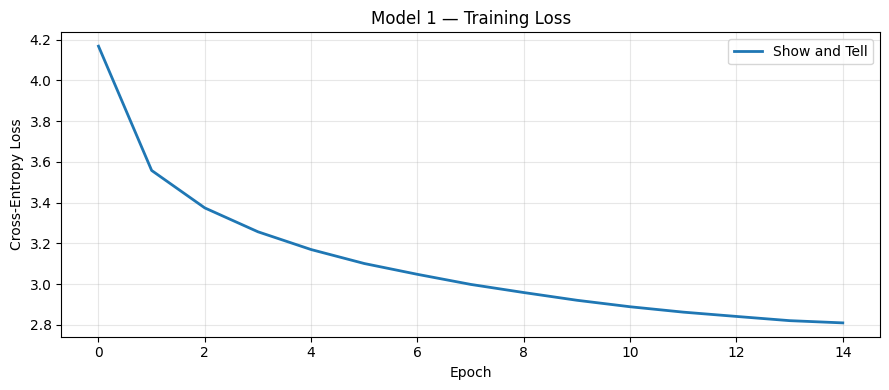

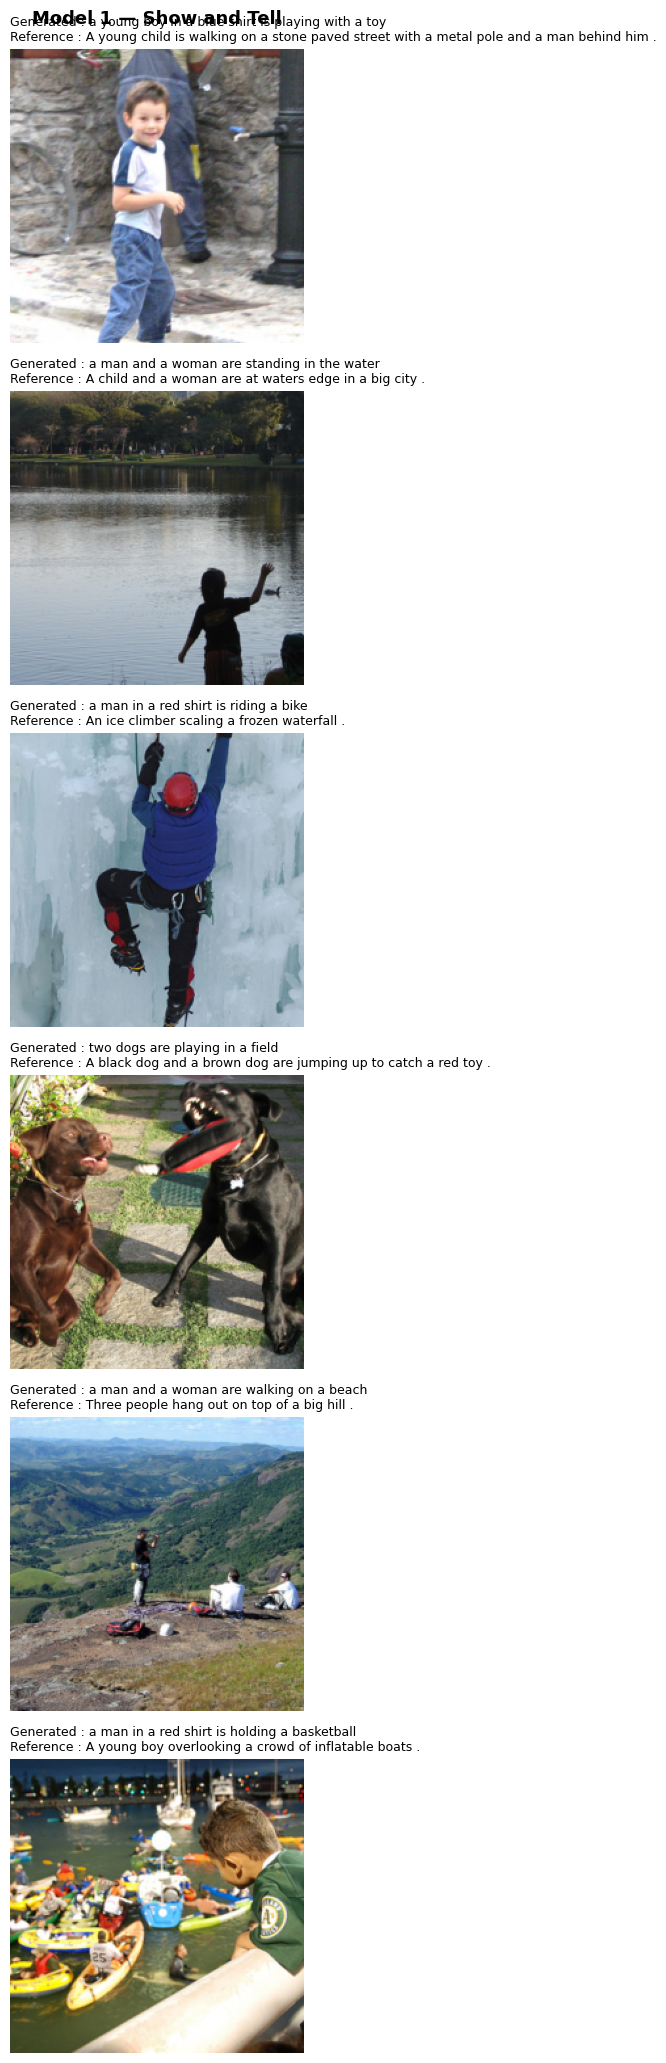

  Perplexity : 18.22
  BLEU-1       : 0.5506
  BLEU-2       : 0.3590
  BLEU-3       : 0.2192
  BLEU-4       : 0.1354


In [23]:
# Training curve
plot_training_curves({"Show and Tell": sat_results["train_losses"]}, title="Model 1 — Training Loss")

# Sample captions
show_sample_captions(sat_encoder, sat_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Model 1 — Show and Tell")

# Summary table
print("=" * 45)
print(f"  Perplexity : {sat_results['perplexity']:.2f}")
for k, v in sat_results["bleu"].items():
    print(f"  {k}       : {v:.4f}")
print("=" * 45)

Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.

**Architecture:**
- ResNet-18 spatial encoder: retains the 7×7 convolutional feature map → (B, 49, 512)
- Additive (Bahdanau) attention: at each decoding step the LSTM attends over the 49 spatial locations
- LSTMCell decoder with context vector concatenated to the word embedding
- Doubly-stochastic attention gate to encourage each feature location to be attended to


In [24]:
# Hyperparameters for Show, Attend and Tell
SATT_ENCODER_DIM  = 512   # channels in the ResNet-18 spatial feature map
SATT_EMBED_DIM    = 256
SATT_DECODER_DIM  = 512
SATT_ATTENTION_DIM = 256
SATT_DROPOUT       = 0.5
SATT_FREEZE_ENC    = False
SATT_LR            = 4e-4
SATT_N_EPOCHS      = 15
SATT_WEIGHT_DECAY  = 1e-4

In [25]:
# ── Encoder (Show, Attend and Tell) ─────────────────────────────────────────
class ShowAttendTellEncoder(nn.Module):
    """
    ResNet-18 with the head removed; retains the 7x7 spatial feature map.
    Outputs (B, 49, 512) — 49 spatial locations, each a 512-d descriptor.
    """
    def __init__(self, freeze: bool = False):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        # Layers up to (and including) layer4 — output: (B, 512, 7, 7)
        self.features = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        )
        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feat = self.features(images)              # (B, 512, 7, 7)
        B, C, H, W = feat.shape
        feat = feat.permute(0, 2, 3, 1)           # (B, 7, 7, 512)
        return feat.reshape(B, H * W, C)          # (B, 49, 512)


# ── Additive (Bahdanau) Attention ────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Bahdanau / additive attention as used in Show, Attend and Tell.
    energy_t = v^T tanh(W_enc * encoder_out + W_dec * h_t)
    alpha_t  = softmax(energy_t)
    context  = sum_i alpha_{t,i} * encoder_out_i
    """
    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attention_dim)
        self.W_dec = nn.Linear(decoder_dim, attention_dim)
        self.v     = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, encoder_out: torch.Tensor, h: torch.Tensor):
        # encoder_out : (B, num_pix, enc_dim)
        # h           : (B, dec_dim)
        enc_proj = self.W_enc(encoder_out)                   # (B, P, attn_dim)
        dec_proj = self.W_dec(h).unsqueeze(1)                # (B, 1, attn_dim)
        energy   = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(-1)  # (B, P)
        alpha    = torch.softmax(energy, dim=-1)             # (B, P)
        context  = (encoder_out * alpha.unsqueeze(-1)).sum(1)# (B, enc_dim)
        return context, alpha


# ── Decoder (Show, Attend and Tell) ──────────────────────────────────────────
class ShowAttendTellDecoder(nn.Module):
    """
    LSTM decoder with Bahdanau attention and doubly-stochastic gate.
    forward()                — teacher-forced training
    generate()               — greedy inference
    generate_with_attention()— greedy inference returning attention weights
    """
    def __init__(self, vocab_size: int, encoder_dim: int, embed_dim: int,
                 decoder_dim: int, attention_dim: int,
                 dropout: float = 0.5, pad_idx: int = 0):
        super().__init__()
        self.pad_idx   = pad_idx
        self.attention = AdditiveAttention(encoder_dim, decoder_dim, attention_dim)
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h    = nn.Linear(encoder_dim, decoder_dim)
        self.init_c    = nn.Linear(encoder_dim, decoder_dim)
        self.lstm      = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.beta_gate = nn.Linear(decoder_dim, encoder_dim)   # doubly-stochastic
        self.drop      = nn.Dropout(dropout)
        self.fc        = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, enc_out: torch.Tensor):
        mean_enc = enc_out.mean(1)                   # (B, enc_dim)
        return torch.tanh(self.init_h(mean_enc)), torch.tanh(self.init_c(mean_enc))

    def forward(self, enc_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """enc_out: (B, P, enc_dim);  captions: (B, max_len)"""
        h, c  = self._init_hidden(enc_out)
        embeds = self.drop(self.embed(captions[:, :-1]))  # (B, T-1, E)
        logits = []
        for t in range(embeds.size(1)):
            ctx, alpha = self.attention(enc_out, h)
            gate = torch.sigmoid(self.beta_gate(h))
            ctx  = gate * ctx
            h, c = self.lstm(torch.cat([embeds[:, t], ctx], dim=-1), (h, c))
            logits.append(self.fc(self.drop(h)))
        return torch.stack(logits, dim=1)           # (B, T-1, V)

    @torch.no_grad()
    def generate(self, enc_out: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        h, c = self._init_hidden(enc_out)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        out  = []
        for _ in range(max_len):
            ctx, _ = self.attention(enc_out, h)
            gate   = torch.sigmoid(self.beta_gate(h))
            ctx    = gate * ctx
            h, c   = self.lstm(torch.cat([self.embed(tok), ctx], dim=-1), (h, c))
            pred   = self.fc(h).argmax(-1)
            out.append(pred)
            tok = pred
        return torch.stack(out, dim=1)              # (B, max_len)

    @torch.no_grad()
    def generate_with_attention(self, enc_out: torch.Tensor, tokenizer,
                                max_len: int = 35):
        """Returns (token_ids (B,T), attention_weights (B,T,P))."""
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        h, c = self._init_hidden(enc_out)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        ids_list, alpha_list = [], []
        for _ in range(max_len):
            ctx, alpha = self.attention(enc_out, h)
            gate = torch.sigmoid(self.beta_gate(h))
            ctx  = gate * ctx
            h, c = self.lstm(torch.cat([self.embed(tok), ctx], dim=-1), (h, c))
            pred = self.fc(h).argmax(-1)
            ids_list.append(pred)
            alpha_list.append(alpha)
            tok = pred
        return torch.stack(ids_list, dim=1), torch.stack(alpha_list, dim=1)


print("ShowAttendTellEncoder and ShowAttendTellDecoder defined.")

ShowAttendTellEncoder and ShowAttendTellDecoder defined.


In [26]:
# Instantiate Model 2
satt_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
satt_decoder = ShowAttendTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=SATT_EMBED_DIM,
    decoder_dim=SATT_DECODER_DIM,
    attention_dim=SATT_ATTENTION_DIM,
    dropout=SATT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(satt_encoder.parameters()) + list(satt_decoder.parameters()))
print(f"Show, Attend and Tell total params: {total_params:,}")

# Train
satt_results = run_training(
    encoder=satt_encoder,
    decoder=satt_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=SATT_LR,
    weight_decay=SATT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="ShowAttendTell",
)

Show, Attend and Tell total params: 16,890,009


KeyboardInterrupt: 

In [ ]:
# Training curves — both models together
plot_training_curves(
    {"Show and Tell": sat_results["train_losses"],
     "Show, Attend and Tell": satt_results["train_losses"]},
    title="Training Loss Comparison"
)

# Sample captions
show_sample_captions(satt_encoder, satt_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Model 2 — Show, Attend and Tell")

# Metric comparison table
print("\n{:<22} {:>10} {:>12}".format("Metric", "Model 1", "Model 2"))
print("-" * 46)
print("{:<22} {:>10.2f} {:>12.2f}".format(
    "Perplexity", sat_results["perplexity"], satt_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>10.4f} {:>12.4f}".format(k, sat_results["bleu"][k], satt_results["bleu"][k]))

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 1.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Attention Visualization (Easy)

**Hypothesis:** If the attention mechanism is working correctly, the model should focus on semantically relevant image regions when generating each word (e.g. attend to a dog region when outputting the word *dog*).

**Experiment:** For a handful of test images we run `generate_with_attention()`, decode the caption word-by-word, and overlay the corresponding 7×7 attention map (bilinearly upsampled to 224×224) on top of the original image.

**Expected outcome:** Meaningful attention maps should show high activations near the objects or scene elements described by each token.


In [ ]:
def visualize_attention_for_image(image_tensor: torch.Tensor,
                                   token_ids: torch.Tensor,
                                   attention_weights: torch.Tensor,
                                   tokenizer,
                                   max_words: int = 12):
    """
    Overlay attention heatmaps on the image for each generated word.
    image_tensor      : (3, H, W) — normalised tensor
    token_ids         : (max_len,) — generated ids (no BOS)
    attention_weights : (max_len, num_pixels) — e.g. (35, 49)
    """
    img_np = denormalize_image(image_tensor.cpu()).permute(1, 2, 0).numpy()
    grid   = int(math.sqrt(attention_weights.shape[-1]))   # 7

    # Decode caption word by word (stop at EOS)
    words = []
    for tid in token_ids.cpu().tolist():
        word = tokenizer.itos.get(tid, "<unk>")
        if word == "<eos>":
            break
        if word not in ("<bos>", "<pad>", "<unk>"):
            words.append((word, tid))
    words = words[:max_words]

    cols = 4
    rows = math.ceil((len(words) + 1) / cols)   # +1 for original image
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = axes.flatten()

    # First panel: original image
    axes[0].imshow(img_np)
    axes[0].set_title("Input image", fontsize=9, weight="bold")
    axes[0].axis("off")

    for idx, (word, tid) in enumerate(words, start=1):
        alpha = attention_weights[idx - 1].cpu()       # (num_pixels,)
        alpha_map = alpha.reshape(grid, grid).numpy()
        # Upsample to image size
        alpha_up = np.array(
            Image.fromarray((alpha_map * 255).astype(np.uint8)).resize(
                (img_np.shape[1], img_np.shape[0]), resample=Image.BILINEAR
            )
        ) / 255.0
        axes[idx].imshow(img_np)
        axes[idx].imshow(alpha_up, alpha=0.55, cmap="hot", vmin=0)
        axes[idx].set_title(f'"{word}"', fontsize=10)
        axes[idx].axis("off")

    for j in range(len(words) + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Attention maps — Show, Attend and Tell", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


# ── Run visualisation on a few test images ───────────────────────────────────
satt_encoder.eval(); satt_decoder.eval()
vis_images, _, _, _, _ = next(iter(test_loader))
vis_images_dev = vis_images[:4].to(DEVICE)

with torch.no_grad():
    enc_out = satt_encoder(vis_images_dev)              # (4, 49, 512)
    tok_ids, attn_weights = satt_decoder.generate_with_attention(enc_out, tokenizer)

for i in range(vis_images_dev.size(0)):
    visualize_attention_for_image(
        image_tensor=vis_images[i],
        token_ids=tok_ids[i],
        attention_weights=attn_weights[i],
        tokenizer=tokenizer,
    )

**Observation (fill in after running):**  
*Describe which words had the most focused attention, whether the model attended to correct regions, and any failure modes you observed.*


## Additional Task 2: Beam Search (Easy)

**Hypothesis:** Beam search should produce more globally coherent captions than greedy decoding because it maintains multiple candidate sequences at each step and therefore avoids locally optimal but globally suboptimal token selections.

**Experiment:** Implement beam search for the Show, Attend and Tell model and compare BLEU scores against greedy decoding on the same test set.


In [ ]:
@torch.no_grad()
def beam_search_single(encoder_out: torch.Tensor, decoder: ShowAttendTellDecoder,
                        tokenizer, beam_size: int = 5, max_len: int = 35) -> list:
    """
    Beam search for a single image.
    encoder_out : (1, num_pixels, encoder_dim)
    Returns list of token ids (best hypothesis, without BOS).
    """
    device = encoder_out.device
    h, c   = decoder._init_hidden(encoder_out)           # (1, dec_dim)

    # Beams: list of (score, token_list, h, c)
    beams     = [(0.0, [tokenizer.bos_idx], h, c)]
    completed = []

    for step in range(max_len):
        all_cands = []
        for score, toks, h_b, c_b in beams:
            tok   = torch.tensor([toks[-1]], dtype=torch.long, device=device)
            emb   = decoder.embed(tok)                   # (1, E)
            ctx, alpha = decoder.attention(encoder_out, h_b)
            gate  = torch.sigmoid(decoder.beta_gate(h_b))
            ctx   = gate * ctx
            h_new, c_new = decoder.lstm(torch.cat([emb, ctx], dim=-1), (h_b, c_b))
            log_probs    = F.log_softmax(decoder.fc(h_new), dim=-1)[0]  # (V,)
            topk_lp, topk_ids = log_probs.topk(beam_size)
            for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                all_cands.append((score + lp, toks + [tid], h_new, c_new))

        # Sort by score
        all_cands.sort(key=lambda x: x[0], reverse=True)

        beams = []
        for score, toks, h_b, c_b in all_cands:
            if toks[-1] == tokenizer.eos_idx:
                # Normalise by length
                completed.append((score / len(toks), toks[1:]))  # strip BOS
            else:
                beams.append((score, toks, h_b, c_b))
            if len(beams) == beam_size:
                break
        if not beams:
            break

    # Add remaining beams
    for score, toks, h_b, c_b in beams:
        completed.append((score / max(len(toks), 1), toks[1:]))

    completed.sort(key=lambda x: x[0], reverse=True)
    return completed[0][1] if completed else [tokenizer.eos_idx]


@torch.no_grad()
def compute_bleu_beam(encoder, decoder, dataloader, tokenizer, device,
                      captions_map: dict, beam_size: int = 5,
                      max_samples: int = 500) -> dict:
    """BLEU computed using beam-search decoded captions."""
    encoder.eval(); decoder.eval()
    references, hypotheses = [], []
    count = 0
    for images, _, _, image_ids, raw_caps in dataloader:
        if count >= max_samples:
            break
        for i, img in enumerate(images):
            img_dev = img.unsqueeze(0).to(device)
            enc_out = encoder(img_dev)            # (1, P, C)
            best    = beam_search_single(enc_out, decoder, tokenizer,
                                         beam_size=beam_size)
            all_caps = captions_map.get(image_ids[i], [raw_caps[i]])
            references.append([tokenize(c) for c in all_caps])
            hyp_str = tokenizer.decode(best, skip_special_tokens=True, stop_at_eos=True)
            hypotheses.append(tokenize(hyp_str))
            count += 1
            if count >= max_samples:
                break

    sf = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=sf),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(.5,.5,0,0), smoothing_function=sf),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=sf),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(.25,.25,.25,.25), smoothing_function=sf),
    }


# Evaluate — greedy vs beam (subset for speed)
print("Evaluating Beam Search (beam_size=5) on 500 test samples …")
beam_bleu = compute_bleu_beam(satt_encoder, satt_decoder, test_loader,
                               tokenizer, DEVICE, test_captions_map,
                               beam_size=5, max_samples=500)

greedy_bleu_subset = compute_bleu(satt_encoder, satt_decoder, test_loader,
                                   tokenizer, DEVICE, test_captions_map,
                                   max_samples=500)

print("\n{:<22} {:>12} {:>12}".format("Metric", "Greedy", "Beam (k=5)"))
print("-" * 48)
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>12.4f} {:>12.4f}".format(k, greedy_bleu_subset[k], beam_bleu[k]))

**Observation (fill in after running):**  
*Compare BLEU scores, inspect a few beam-search captions vs greedy, and discuss whether the improvement is consistent.*


## Additional Task 3: Alternative Attention Mechanisms (Moderate)

**Hypothesis:** Scaled dot-product attention (as used in transformer architectures) may converge faster or to a better optimum than additive Bahdanau attention because the multiplicative interaction captures alignment more sharply.

**Experiment:** Replace `AdditiveAttention` with `ScaledDotProductAttention` inside a copy of the Show, Attend and Tell decoder and train it under identical conditions. Compare BLEU and training curves.


In [ ]:
# ── Scaled Dot-Product Attention ────────────────────────────────────────────
class ScaledDotProductAttention(nn.Module):
    """
    Dot-product attention: score = (W_dec * h) · (W_enc * e_i) / sqrt(d)
    where d is the attention dimension.
    """
    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc  = nn.Linear(encoder_dim, attention_dim, bias=False)
        self.W_dec  = nn.Linear(decoder_dim, attention_dim, bias=False)
        self.scale  = math.sqrt(attention_dim)

    def forward(self, encoder_out: torch.Tensor, h: torch.Tensor):
        enc_proj = self.W_enc(encoder_out)                        # (B, P, d)
        dec_proj = self.W_dec(h).unsqueeze(2)                     # (B, d, 1)
        energy   = torch.bmm(enc_proj, dec_proj).squeeze(-1) / self.scale  # (B, P)
        alpha    = torch.softmax(energy, dim=-1)
        context  = (encoder_out * alpha.unsqueeze(-1)).sum(1)
        return context, alpha


# ── Decoder variant using dot-product attention ──────────────────────────────
class DotProductAttendTellDecoder(ShowAttendTellDecoder):
    """
    Identical to ShowAttendTellDecoder but uses ScaledDotProductAttention.
    Inherits forward / generate / generate_with_attention unchanged.
    """
    def __init__(self, vocab_size, encoder_dim, embed_dim, decoder_dim,
                 attention_dim, dropout=0.5, pad_idx=0):
        super().__init__(vocab_size, encoder_dim, embed_dim, decoder_dim,
                         attention_dim, dropout, pad_idx)
        # Override the attention module
        self.attention = ScaledDotProductAttention(encoder_dim, decoder_dim, attention_dim)


# ── Train the dot-product variant ────────────────────────────────────────────
dp_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
dp_decoder = DotProductAttendTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=SATT_EMBED_DIM,
    decoder_dim=SATT_DECODER_DIM,
    attention_dim=SATT_ATTENTION_DIM,
    dropout=SATT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

dp_results = run_training(
    encoder=dp_encoder,
    decoder=dp_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=SATT_LR,
    weight_decay=SATT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="DotProductAttention",
)

In [ ]:
# Compare training curves and metrics: Bahdanau vs Dot-Product
plot_training_curves(
    {"Bahdanau (Additive)": satt_results["train_losses"],
     "Scaled Dot-Product":  dp_results["train_losses"]},
    title="Attention Mechanism Comparison — Training Loss"
)

print("\n{:<22} {:>14} {:>16}".format("Metric", "Bahdanau", "Dot-Product"))
print("-" * 54)
print("{:<22} {:>14.2f} {:>16.2f}".format(
    "Perplexity", satt_results["perplexity"], dp_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>14.4f} {:>16.4f}".format(
        k, satt_results["bleu"][k], dp_results["bleu"][k]))

**Observation (fill in after running):**  
*Discuss convergence speed, final BLEU, and whether one attention type produces qualitatively better captions.*


## Additional Task 4: Transformer-Based Decoder (Hard)

**Hypothesis:** A transformer decoder with multi-head cross-attention to the spatial image features can model long-range dependencies more effectively than an LSTM, potentially achieving higher BLEU scores.

**Experiment:** Re-use the same `ShowAttendTellEncoder` (spatial 49×512 features) and replace the LSTM with a stack of `nn.TransformerDecoderLayer`s. Compare training curves and BLEU against both LSTM models.


In [ ]:
# ── Transformer-based Captioner ─────────────────────────────────────────────
class TransformerDecoder(nn.Module):
    """
    Transformer decoder for image captioning.
    - Memory: spatial image features from ShowAttendTellEncoder → (B, 49, 512)
    - Target: token embeddings + sinusoidal-style learnable positional encoding
    - Outputs token logits (B, T-1, vocab_size) during training,
      greedy token ids (B, max_len) during inference.
    """
    def __init__(self, vocab_size: int, encoder_dim: int = 512,
                 embed_dim: int = 256, nhead: int = 4,
                 num_layers: int = 3, ffn_dim: int = 1024,
                 dropout: float = 0.1, max_pos: int = 60,
                 pad_idx: int = 0):
        super().__init__()
        assert embed_dim % nhead == 0, "embed_dim must be divisible by nhead"
        self.pad_idx  = pad_idx
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_emb  = nn.Embedding(max_pos, embed_dim)
        self.enc_proj = nn.Linear(encoder_dim, embed_dim)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers,
                                              norm=nn.LayerNorm(embed_dim))
        self.fc      = nn.Linear(embed_dim, vocab_size)
        self.drop    = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight, std=0.02)

    @staticmethod
    def _causal_mask(sz: int, device) -> torch.Tensor:
        return torch.triu(torch.ones(sz, sz, device=device, dtype=torch.bool), diagonal=1)

    def forward(self, enc_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """
        enc_out  : (B, num_pixels, encoder_dim)  — from spatial encoder
        captions : (B, max_len)  — includes BOS; target is captions[:, 1:]
        """
        B, device = captions.size(0), captions.device
        tgt = captions[:, :-1]                             # (B, T-1)
        T   = tgt.size(1)

        pos  = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x    = self.drop(self.embed(tgt) + self.pos_emb(pos))   # (B, T-1, E)

        mem  = self.enc_proj(enc_out)                      # (B, P, E)
        mask = self._causal_mask(T, device)
        pad_mask = (tgt == self.pad_idx)                   # (B, T-1) — True = ignore

        out  = self.decoder(x, mem, tgt_mask=mask, tgt_key_padding_mask=pad_mask)
        return self.fc(out)                                # (B, T-1, V)

    @torch.no_grad()
    def generate(self, enc_out: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        mem = self.enc_proj(enc_out)                       # (B, P, E)
        generated = torch.full((B, 1), tokenizer.bos_idx, dtype=torch.long, device=device)

        for step in range(max_len):
            T   = generated.size(1)
            pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
            x   = self.embed(generated) + self.pos_emb(pos)
            msk = self._causal_mask(T, device)
            out = self.decoder(x, mem, tgt_mask=msk)
            nxt = self.fc(out[:, -1]).argmax(-1, keepdim=True)   # (B, 1)
            generated = torch.cat([generated, nxt], dim=1)
            if (nxt == tokenizer.eos_idx).all():
                break

        return generated[:, 1:]   # strip BOS  →  (B, ≤max_len)


# Shared spatial encoder (same weights as SATT for fair comparison)
tr_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
tr_decoder = TransformerDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=256,
    nhead=4,
    num_layers=3,
    ffn_dim=1024,
    dropout=0.1,
    max_pos=MAX_LEN + 5,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(tr_encoder.parameters()) + list(tr_decoder.parameters()))
print(f"Transformer Captioner total params: {total_params:,}")

tr_results = run_training(
    encoder=tr_encoder,
    decoder=tr_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=1e-4,                  # transformers prefer a lower, warmed-up lr
    weight_decay=1e-4,
    captions_map=test_captions_map,
    model_name="TransformerDecoder",
)

In [ ]:
# All three models compared
plot_training_curves(
    {"Show and Tell (LSTM)":          sat_results["train_losses"],
     "Show, Attend and Tell (LSTM)":  satt_results["train_losses"],
     "Transformer Decoder":           tr_results["train_losses"]},
    title="Training Loss — All Models"
)

# Sample captions
show_sample_captions(tr_encoder, tr_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Transformer Decoder — Generated Captions")

# Final metric table
print("\n{:<26} {:>10} {:>10} {:>14}".format(
    "Metric", "M1 (SaT)", "M2 (SATaT)", "M3 (Transf.)"))
print("-" * 62)
print("{:<26} {:>10.2f} {:>10.2f} {:>14.2f}".format(
    "Perplexity",
    sat_results["perplexity"], satt_results["perplexity"], tr_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<26} {:>10.4f} {:>10.4f} {:>14.4f}".format(
        k, sat_results["bleu"][k], satt_results["bleu"][k], tr_results["bleu"][k]))

**Observation (fill in after running):**  
*Discuss differences in convergence, final BLEU, qualitative caption quality, and what you think drives any gap between the LSTM and transformer decoders on this relatively small dataset.*


## Skipped Optional Tasks

The following optional tasks were intentionally skipped because they require external tools or resources that are not included in the provided files:

| Task | Reason Skipped |
|------|----------------|
| **Pretrained Word Embeddings (GloVe / Word2Vec)** | Requires downloading external GloVe/Word2Vec binary files (~800 MB). Not available in the provided environment; would need `gensim` or manual download from `nlp.stanford.edu/data/glove.6B.zip`. |
| **Experiment Tracking (W&B)** | Requires a Weights & Biases account and API key. Integrate by adding `wandb.init(project=...)` and `wandb.log({...})` inside `run_training()` once the `wandb` package is installed and authenticated. |
